
   ÉTAPE 1 — CHARGEMENT

✓ Table chargée : (110181, 21)

   PHASE 1 — VUE GLOBALE

Taux de retard global : 6.59%
Retard moyen (jours)  : -12.0
Retard médian (jours) : -13.0


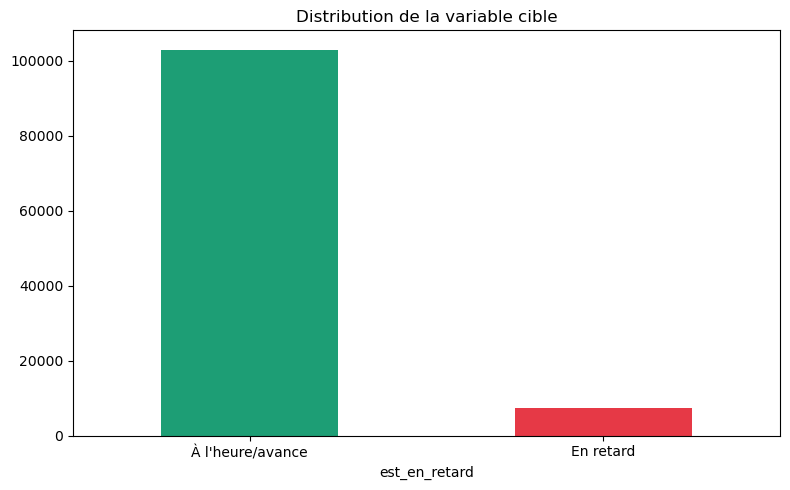


   PHASE 2 — DISTANCE vs RETARD

--- Distance moyenne selon le statut ---
                     mean      median
est_en_retard                        
0              584.235882  425.207571
1              762.134623  529.173022

Corrélation distance_km / retard_jours : -0.078


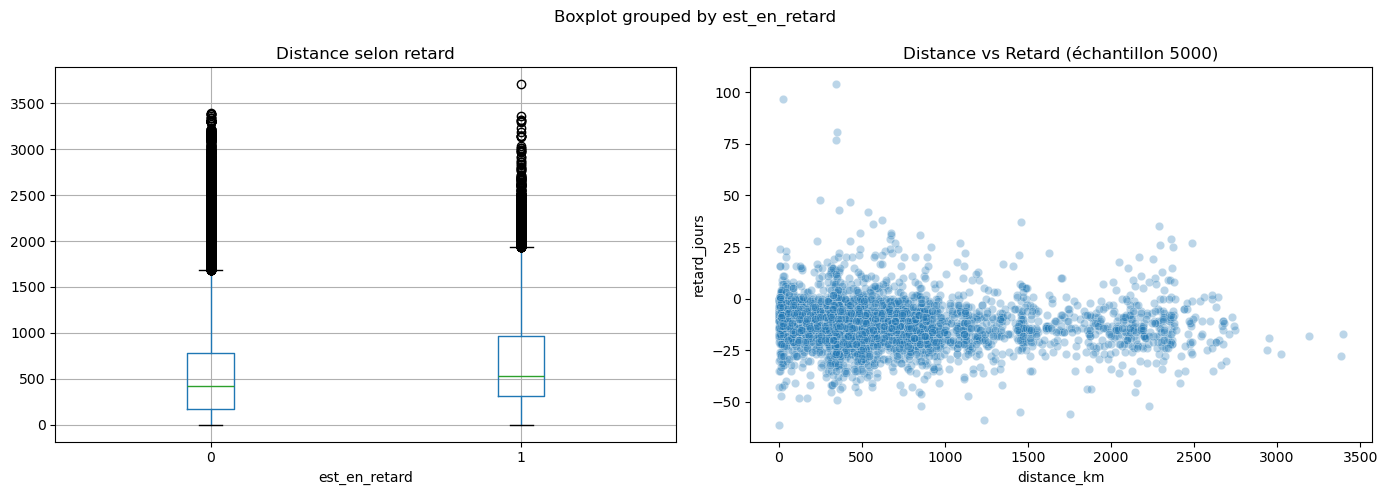


   PHASE 3 — POIDS / VOLUME vs RETARD

--- Poids et volume moyens selon le statut ---
               product_weight_g    volume_cm3
est_en_retard                                
0                   2063.164276  15035.691074
1                   2460.382074  17111.917803

Corrélation poids / retard  : 0.012
Corrélation volume / retard : 0.012

   PHASE 4 — MEME_ETAT vs RETARD

Taux de retard (%) selon meme_etat :
est_en_retard          0         1
meme_etat                         
0              92.192833  7.807167
1              95.552043  4.447957


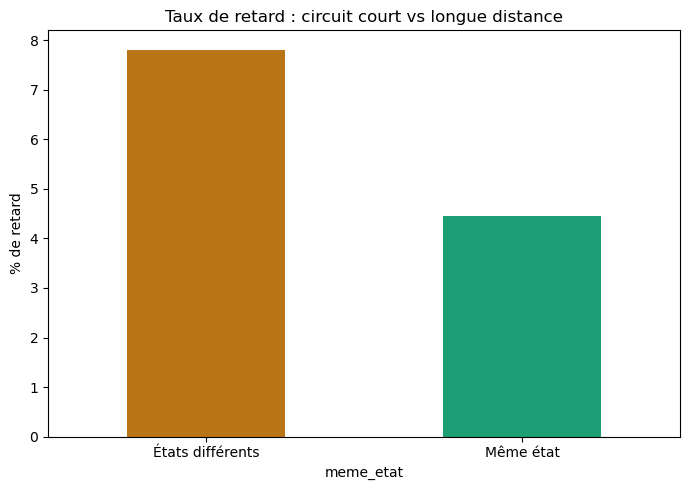


   PHASE 5 — VALIDATION anomalie_multivariee

Taux de retard (%) selon anomalie_multivariee :
est_en_retard                 0          1
anomalie_multivariee                      
0                     93.727139   6.272861
1                     77.691606  22.308394

→ Ratio : les anomalies ont 3.6x plus de risque de retard

   PHASE 6 — SAISONNALITÉ

mois_achat
1      5.44
2     11.78
3     14.50
4      4.61
5      5.27
6      1.75
7      3.16
8      4.73
9      4.45
10     3.73
11    11.91
12     7.30
Name: est_en_retard, dtype: float64


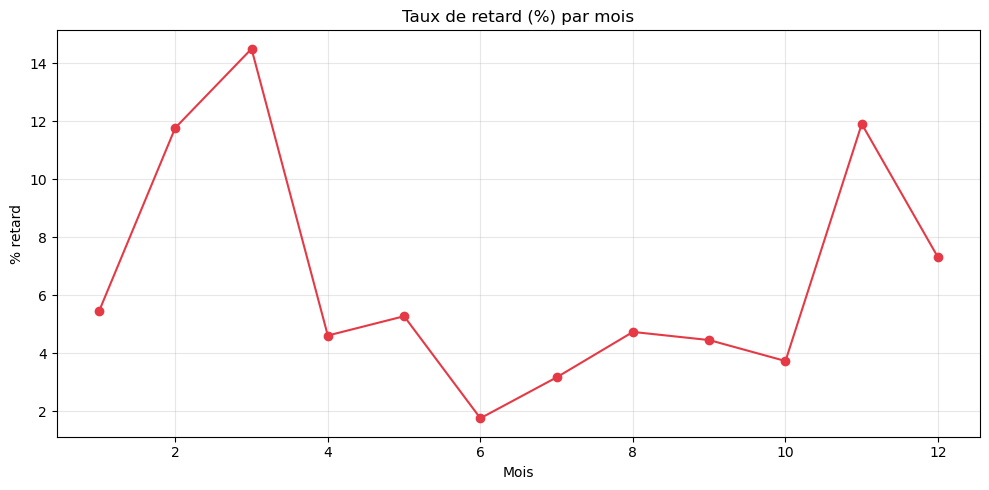


   PHASE 7 — GÉOGRAPHIE : TOP ÉTATS À RISQUE

Top 10 états clients avec le + de retard (min 100 commandes) :
                 mean  count
customer_state              
AL              20.84    427
MA              18.02    799
SE              16.27    375
CE              13.60   1426
PI              13.58    523
BA              11.90   3682
RJ              11.62  14142
PA              11.31   1052
PB              10.75    586
ES              10.74   2225

   RÉCAPITULATIF DES CORRÉLATIONS



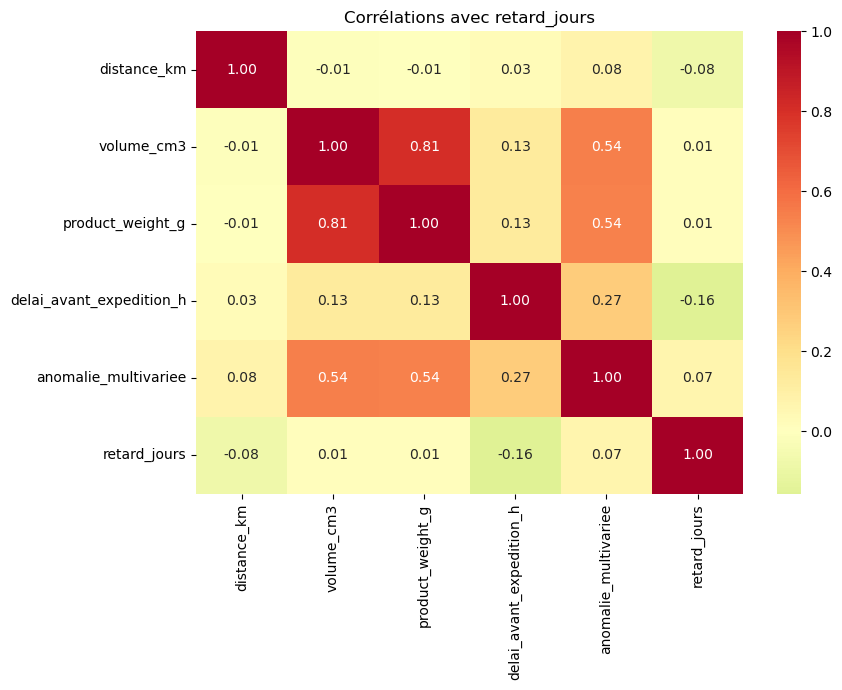


→ Prochain : 04_feature_engineering.ipynb


In [ ]:
# ============================================================
# 03_eda.ipynb — ANALYSE EXPLORATOIRE
# Problématique : facteurs du retard de livraison
# ============================================================

import sys
sys.path.append('..')
from src.utils import *
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 1 — CHARGEMENT")
print("="*60 + "\n")
# -------------------------------------------------------

base = pd.read_csv('../data/processed/logistique_base.csv')
print(f"✓ Table chargée : {base.shape}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 1 — VUE GLOBALE")
print("="*60 + "\n")
# -------------------------------------------------------

print(f"Taux de retard global : {base['est_en_retard'].mean()*100:.2f}%")
print(f"Retard moyen (jours)  : {base['retard_jours'].mean():.1f}")
print(f"Retard médian (jours) : {base['retard_jours'].median():.1f}")

fig, ax = plt.subplots(figsize=(8,5))
base['est_en_retard'].value_counts().plot(kind='bar', color=['#1D9E75','#E63946'], ax=ax)
ax.set_xticklabels(['À l\'heure/avance', 'En retard'], rotation=0)
ax.set_title('Distribution de la variable cible')
plt.tight_layout()
plt.savefig('../reports/figures/eda_01_distribution_cible.png', dpi=150)
plt.show()


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 2 — DISTANCE vs RETARD")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- Distance moyenne selon le statut ---")
print(base.groupby('est_en_retard')['distance_km'].agg(['mean','median']))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
base.boxplot(column='distance_km', by='est_en_retard', ax=axes[0])
axes[0].set_title('Distance selon retard')
axes[0].set_xlabel('est_en_retard')

# Corrélation
corr_dist = base[['distance_km','retard_jours']].corr().iloc[0,1]
print(f"\nCorrélation distance_km / retard_jours : {corr_dist:.3f}")

sns.scatterplot(data=base.sample(5000, random_state=42),
                 x='distance_km', y='retard_jours', alpha=0.3, ax=axes[1])
axes[1].set_title('Distance vs Retard (échantillon 5000)')
plt.tight_layout()
plt.savefig('../reports/figures/eda_02_distance_retard.png', dpi=150)
plt.show()


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 3 — POIDS / VOLUME vs RETARD")
print("="*60 + "\n")
# -------------------------------------------------------

print("--- Poids et volume moyens selon le statut ---")
print(base.groupby('est_en_retard')[['product_weight_g','volume_cm3']].mean())

corr_poids = base[['product_weight_g','retard_jours']].corr().iloc[0,1]
corr_volume = base[['volume_cm3','retard_jours']].corr().iloc[0,1]
print(f"\nCorrélation poids / retard  : {corr_poids:.3f}")
print(f"Corrélation volume / retard : {corr_volume:.3f}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 4 — MEME_ETAT vs RETARD")
print("="*60 + "\n")
# -------------------------------------------------------

tab = pd.crosstab(base['meme_etat'], base['est_en_retard'], normalize='index') * 100
print("Taux de retard (%) selon meme_etat :")
print(tab)

fig, ax = plt.subplots(figsize=(7,5))
tab[1].plot(kind='bar', color=['#BA7517','#1D9E75'], ax=ax)
ax.set_xticklabels(['États différents', 'Même état'], rotation=0)
ax.set_ylabel('% de retard')
ax.set_title('Taux de retard : circuit court vs longue distance')
plt.tight_layout()
plt.savefig('../reports/figures/eda_03_meme_etat.png', dpi=150)
plt.show()


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 5 — VALIDATION anomalie_multivariee")
print("="*60 + "\n")
# -------------------------------------------------------

tab2 = pd.crosstab(base['anomalie_multivariee'], base['est_en_retard'], normalize='index') * 100
print("Taux de retard (%) selon anomalie_multivariee :")
print(tab2)
print(f"\n→ Ratio : les anomalies ont {tab2.loc[1,1]/tab2.loc[0,1]:.1f}x plus de risque de retard")


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 6 — SAISONNALITÉ")
print("="*60 + "\n")
# -------------------------------------------------------

taux_mois = base.groupby('mois_achat')['est_en_retard'].mean() * 100
print(taux_mois.round(2))

fig, ax = plt.subplots(figsize=(10,5))
taux_mois.plot(kind='line', marker='o', color='#E63946', ax=ax)
ax.set_title('Taux de retard (%) par mois')
ax.set_xlabel('Mois')
ax.set_ylabel('% retard')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/eda_04_saisonnalite.png', dpi=150)
plt.show()


# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 7 — GÉOGRAPHIE : TOP ÉTATS À RISQUE")
print("="*60 + "\n")
# -------------------------------------------------------

taux_etat = (base.groupby('customer_state')['est_en_retard']
             .agg(['mean','count'])
             .query('count > 100')
             .sort_values('mean', ascending=False))
taux_etat['mean'] = (taux_etat['mean']*100).round(2)
print("Top 10 états clients avec le + de retard (min 100 commandes) :")
print(taux_etat.head(10))


# -------------------------------------------------------
print("\n" + "="*60)
print("   RÉCAPITULATIF DES CORRÉLATIONS")
print("="*60 + "\n")
# -------------------------------------------------------

vars_num = ['distance_km','volume_cm3','product_weight_g',
            'delai_avant_expedition_h','anomalie_multivariee','retard_jours']
corr_matrix = base[vars_num].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, ax=ax)
ax.set_title('Corrélations avec retard_jours')
plt.tight_layout()
plt.savefig('../reports/figures/eda_05_correlations.png', dpi=150)
plt.show()

print("\n→ Prochain : 04_feature_engineering.ipynb")